## Importación Data

In [27]:
import pandas as pd
import numpy as np

data = pd.read_csv("synthetic_edu_insight360.csv",
                   low_memory=False ,
                    encoding='utf-8',      # o 'latin-1' si hay caracteres especiales
                    sep=',',               # separador (por defecto es coma)
                    header=0,              # fila que contiene los nombres de columnas
                    index_col=None)        # si quieres usar una columna como índice

In [28]:
# Resumen general
data.info()
print('data.columns:',data.columns)
print('data.shape:',data.shape)
data.head(100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   study_hours_wk                 1000 non-null   float64
 1   sleep_hours                    1000 non-null   float64
 2   lms_activity_rate              1000 non-null   float64
 3   attendance_rate                1000 non-null   float64
 4   assignments_on_time_rate       1000 non-null   float64
 5   procrastination_index          1000 non-null   float64
 6   self_efficacy                  1000 non-null   float64
 7   stress                         1000 non-null   float64
 8   internet_quality               1000 non-null   float64
 9   part_time_job_hours            1000 non-null   float64
 10  commute_min                    1000 non-null   float64
 11  social_support                 1000 non-null   float64
 12  screen_time_nonstudy_hr        1000 non-null   fl

,study_hours_wk,sleep_hours,lms_activity_rate,attendance_rate,assignments_on_time_rate,procrastination_index,self_efficacy,stress,internet_quality,part_time_job_hours,...,grade_Estadística_prior_20,grade_Estadística_current_20,grade_Ética_prior_20,grade_Ética_current_20,student_id,cluster_label_true,major,primary_device,internet_type,cohort
0,13.675912,7.844978,66.964681,81.874974,68.209130,47.941762,60.678050,43.664949,72.620031,7.339488,...,15.303218,10.537708,15.401349,12.490938,620.436883,A,Psicología,Laptop,Fibra,2023
1,13.466737,8.179369,72.621295,84.235342,70.308999,47.908609,56.925206,42.669400,67.852973,6.860263,...,14.786166,11.526852,15.418243,11.440954,780.919440,A,Psicología,Laptop,Fibra,2025
2,14.464209,8.176980,70.569146,81.577863,72.519438,47.931619,56.084815,40.597457,72.283311,7.390099,...,15.310248,10.572145,15.861150,12.246119,709.528028,A,Industrial,Smartphone,Fibra,2025
3,12.957480,8.436137,77.400928,87.668652,73.797887,46.902252,56.388493,43.096292,68.025160,7.110476,...,15.798037,10.362166,16.575629,12.663074,827.095583,A,Sistemas,Laptop,Fibra,2024
4,12.752495,8.148688,74.805515,81.846365,73.153495,45.946799,57.239238,41.892244,69.230942,6.305688,...,15.916237,11.453137,14.954452,12.286619,649.522843,A,Sistemas,Smartphone,Cable,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,14.981113,8.178626,70.474349,84.074582,74.965438,49.617846,56.122101,43.039980,74.954125,6.537784,...,14.297841,10.938735,16.549958,11.440954,827.095583,A,Industrial,Laptop,Fibra,2023
96,16.027039,8.138058,59.790802,80.369037,69.355406,49.151411,56.407999,41.584623,78.758770,6.304894,...,14.849100,10.619937,16.091420,12.632223,577.207038,A,Administración,Desktop,Fibra,2022
97,14.282894,8.165541,78.995949,78.880489,77.423741,46.676387,56.906972,39.345230,70.687062,6.929951,...,15.436814,11.316206,15.653683,12.352014,629.299032,A,Sistemas,Laptop,Cable,2024
98,13.025883,8.213527,72.431439,83.413709,71.840310,45.763075,59.350848,43.585035,72.894427,5.770351,...,16.158946,10.623658,15.750190,12.704891,670.450443,A,Sistemas,Laptop,Cable,2022


In [29]:
cols_to_drop = [
    "commute_min",
    "lms_activity_rate",
    "lms_quiz_rate",
    "lms_forum_rate",
    "lms_resource_rate",
    "lms_submission_rate",
    "primary_device",
    "internet_type",
    "internet_quality",
    "major"
]

# Elimina columnas (errors='ignore' evita error si alguna no existe)
df_reduced = data.drop(columns=cols_to_drop, errors="ignore")

df_reduced.info()
df_reduced.head(100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   study_hours_wk                 1000 non-null   float64
 1   sleep_hours                    1000 non-null   float64
 2   attendance_rate                1000 non-null   float64
 3   assignments_on_time_rate       1000 non-null   float64
 4   procrastination_index          1000 non-null   float64
 5   self_efficacy                  1000 non-null   float64
 6   stress                         1000 non-null   float64
 7   part_time_job_hours            1000 non-null   float64
 8   social_support                 1000 non-null   float64
 9   screen_time_nonstudy_hr        1000 non-null   float64
 10  extracurricular_hours          1000 non-null   float64
 11  habit_consistency              1000 non-null   float64
 12  age                            1000 non-null   fl

,study_hours_wk,sleep_hours,attendance_rate,assignments_on_time_rate,procrastination_index,self_efficacy,stress,part_time_job_hours,social_support,screen_time_nonstudy_hr,...,grade_Programación_current_20,grade_Comunicación_prior_20,grade_Comunicación_current_20,grade_Estadística_prior_20,grade_Estadística_current_20,grade_Ética_prior_20,grade_Ética_current_20,student_id,cluster_label_true,cohort
0,13.675912,7.844978,81.874974,68.209130,47.941762,60.678050,43.664949,7.339488,66.881844,3.336467,...,14.975731,12.275895,13.428365,15.303218,10.537708,15.401349,12.490938,620.436883,A,2023
1,13.466737,8.179369,84.235342,70.308999,47.908609,56.925206,42.669400,6.860263,66.025075,3.045431,...,15.867908,11.807704,14.694829,14.786166,11.526852,15.418243,11.440954,780.919440,A,2025
2,14.464209,8.176980,81.577863,72.519438,47.931619,56.084815,40.597457,7.390099,65.185466,3.282903,...,15.537151,12.534446,13.766255,15.310248,10.572145,15.861150,12.246119,709.528028,A,2025
3,12.957480,8.436137,87.668652,73.797887,46.902252,56.388493,43.096292,7.110476,67.123173,3.643118,...,15.960805,12.681777,14.379387,15.798037,10.362166,16.575629,12.663074,827.095583,A,2024
4,12.752495,8.148688,81.846365,73.153495,45.946799,57.239238,41.892244,6.305688,67.281841,3.219484,...,15.521100,12.914777,14.493728,15.916237,11.453137,14.954452,12.286619,649.522843,A,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,14.981113,8.178626,84.074582,74.965438,49.617846,56.122101,43.039980,6.537784,64.571799,2.673866,...,15.947633,11.688737,13.361246,14.297841,10.938735,16.549958,11.440954,827.095583,A,2023
96,16.027039,8.138058,80.369037,69.355406,49.151411,56.407999,41.584623,6.304894,65.124262,3.405435,...,15.657450,11.688737,13.260491,14.849100,10.619937,16.091420,12.632223,577.207038,A,2022
97,14.282894,8.165541,78.880489,77.423741,46.676387,56.906972,39.345230,6.929951,66.974571,3.088819,...,14.806018,13.478802,13.995782,15.436814,11.316206,15.653683,12.352014,629.299032,A,2024
98,13.025883,8.213527,83.413709,71.840310,45.763075,59.350848,43.585035,5.770351,69.595586,3.324547,...,15.623165,12.324100,13.838178,16.158946,10.623658,15.750190,12.704891,670.450443,A,2022


#### 📘 Diccionario de Datos (versión reducida final)

##### 🔹 Identificación y contexto
| Variable          | Tipo       | Rango / Valores                                         | Descripción |
|-------------------|-----------|--------------------------------------------------------|-------------|
| student_id        | int       | 1–1000                                                 | Identificador único del estudiante. |
| cohort            | categórica| {2023-II, 2024-I, 2024-II, 2025-I}                     | Cohorte académica. |
| year_of_study     | int       | 1–5                                                    | Año de estudios. |
| credits_enrolled  | int       | 12–26                                                  | Créditos matriculados en el periodo. |

---

##### 🔹 Demográficos
| Variable | Tipo | Rango | Descripción |
|----------|------|-------|-------------|
| age      | int  | 16–35 | Edad en años. |

---

##### 🔹 Hábitos y bienestar
| Variable                 | Tipo  | Rango   | Descripción |
|--------------------------|-------|---------|-------------|
| study_hours_wk           | float | 2–35    | Horas de estudio por semana. |
| sleep_hours              | float | 4.5–9.5 | Horas promedio de sueño por día. |
| habit_consistency        | float | 0.20–0.99 | Consistencia de hábitos (0–1). |
| procrastination_index    | float | 0.10–0.95 | Procrastinación (0–1, ↑ peor). |
| self_efficacy            | float | 1.5–5.0 | Autoeficacia percibida (Likert). |
| stress                   | float | 1.5–5.0 | Estrés percibido (Likert). |
| social_support           | float | 1.0–5.0 | Apoyo social percibido (Likert). |
| screen_time_nonstudy_hr  | float | 0.5–6.0 | Horas/día en pantalla no académica. |
| extracurricular_hours    | float | 0–10    | Horas/semana en actividades extracurriculares. |
| part_time_job_hours      | float | 0–35    | Horas/semana de trabajo remunerado. |

---

##### 🔹 Asistencia y cumplimiento
| Variable               | Tipo  | Rango       | Descripción |
|------------------------|-------|-------------|-------------|
| attendance_rate        | float | 0.20–0.99   | Asistencia total (0–1). |
| attendance_lecture     | float | ≈0.20–0.99  | Asistencia a clases teóricas (coherente con attendance_rate). |
| attendance_lab         | float | ≈0.20–0.99  | Asistencia a laboratorios (coherente con attendance_rate). |
| assignments_on_time_rate | float | 0.20–0.99 | Entregas puntuales (0–1). |

---

##### 🔹 Rendimiento académico (5 cursos × 2 periodos)
**Cursos incluidos**: Matemáticas, Programación, Comunicación, Estadística, Ética.  

Cada curso tiene **4 variables**:

| Variable                  | Tipo  | Rango     | Descripción |
|---------------------------|-------|-----------|-------------|
| grade_X_prior_20          | float | 8–20      | Nota previa (escala 0–20). |
| grade_X_current_20        | float | 9–20      | Nota actual (escala 0–20). |
| grade_X_prior_pct         | float | 40–100    | Nota previa (%) = prior_20×5. |
| grade_X_current_pct       | float | 45–100    | Nota actual (%) = current_20×5. |

**Ejemplos concretos por curso**:
- Matemáticas → `grade_Matemáticas_prior_20`, `grade_Matemáticas_current_20`, `grade_Matemáticas_prior_pct`, `grade_Matemáticas_current_pct`
- Programación → `grade_Programación_prior_20`, `grade_Programación_current_20`, `grade_Programación_prior_pct`, `grade_Programación_current_pct`
- Comunicación → `grade_Comunicación_prior_20`, `grade_Comunicación_current_20`, `grade_Comunicación_prior_pct`, `grade_Comunicación_current_pct`
- Estadística → `grade_Estadística_prior_20`, `grade_Estadística_current_20`, `grade_Estadística_prior_pct`, `grade_Estadística_current_pct`
- Ética → `grade_Ética_prior_20`, `grade_Ética_current_20`, `grade_Ética_prior_pct`, `grade_Ética_current_pct`

---

##### 🔹 Posibles Clusters (Perfiles Latentes, sin LMS)
> Perfiles construidos con variables de hábitos, asistencia, bienestar y rendimiento académico.

1. **High Achievers (Alto Rendimiento)**  
   - Muchas horas de estudio.  
   - Sueño adecuado.  
   - Hábitos consistentes, alta autoeficacia.  
   - Estrés bajo.  
   - Alta asistencia y puntualidad en entregas.  
   - Notas altas en todos los cursos (16–20).  

2. **Struggling & Sleep-Deprived (Con dificultades)**  
   - Estudian poco y duermen poco.  
   - Alta procrastinación, estrés alto.  
   - Autoeficacia baja.  
   - Asistencia aceptable pero no óptima.  
   - Riesgo académico, notas bajas (≈11–13).  

3. **Passive but Steady (Regulares)**  
   - Estudio moderado, sueño regular.  
   - Estrés y procrastinación medios.  
   - Cumplen con asistencia y entregas.  
   - Rendimiento medio (≈13–15).  

4. **Working Constraints (Limitados por trabajo/tiempo)**  
   - Pocas horas de estudio.  
   - Sueño reducido.  
   - Alta carga laboral y responsabilidades externas.  
   - Estrés alto.  
   - Cumplen parcialmente con asistencia y entregas.  
   - Notas intermedias (≈12–14).  

## PCA

In [30]:
# Manejo de datos
import pandas as pd
import numpy as np

# Preprocesamiento
from sklearn.preprocessing import StandardScaler

# PCA
from sklearn.decomposition import PCA

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
#Paso 1 - Selección y limpieza de columnas

# === 1. Eliminar columnas irrelevantes ===
cols_drop = ["student_id", "cluster_label_true"]  

# === 2. Eliminar duplicados (quedarse con notas en 20)
cols_drop += [c for c in df_reduced.columns if c.endswith("_pct")]

# === 3. Eliminar cohort (categórica) ===
cols_drop += ["cohort"]

df_clean = df_reduced.drop(columns=cols_drop, errors="ignore").copy()
df_clean.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   study_hours_wk                 1000 non-null   float64
 1   sleep_hours                    1000 non-null   float64
 2   attendance_rate                1000 non-null   float64
 3   assignments_on_time_rate       1000 non-null   float64
 4   procrastination_index          1000 non-null   float64
 5   self_efficacy                  1000 non-null   float64
 6   stress                         1000 non-null   float64
 7   part_time_job_hours            1000 non-null   float64
 8   social_support                 1000 non-null   float64
 9   screen_time_nonstudy_hr        1000 non-null   float64
 10  extracurricular_hours          1000 non-null   float64
 11  habit_consistency              1000 non-null   float64
 12  age                            1000 non-null   fl

In [32]:
#Paso 2 – Escalado de variables
from sklearn.preprocessing import StandardScaler
# Crear el escalador
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_clean)

# Convertir de nuevo a DataFrame para ver resultados
df_scaled = pd.DataFrame(data_scaled, columns=df_clean.columns)

# Verificar estadísticas (debe ser media≈0 y std≈1)
print("\nMedia de cada variable:\n", df_scaled.mean().round(2))
print("\nDesviación estándar de cada variable:\n", df_scaled.std().round(2))

# Imprimir primeras filas
df_scaled.head(5)


Media de cada variable:
 study_hours_wk                  -0.0
sleep_hours                      0.0
attendance_rate                  0.0
assignments_on_time_rate         0.0
procrastination_index           -0.0
self_efficacy                   -0.0
stress                          -0.0
part_time_job_hours             -0.0
social_support                   0.0
screen_time_nonstudy_hr         -0.0
extracurricular_hours           -0.0
habit_consistency                0.0
age                              0.0
credits_enrolled                 0.0
year_of_study                    0.0
attendance_lecture               0.0
attendance_lab                   0.0
grade_Matemáticas_prior_20       0.0
grade_Matemáticas_current_20     0.0
grade_Programación_prior_20      0.0
grade_Programación_current_20    0.0
grade_Comunicación_prior_20      0.0
grade_Comunicación_current_20    0.0
grade_Estadística_prior_20      -0.0
grade_Estadística_current_20     0.0
grade_Ética_prior_20             0.0
grade_Ética_

,study_hours_wk,sleep_hours,attendance_rate,assignments_on_time_rate,procrastination_index,self_efficacy,stress,part_time_job_hours,social_support,screen_time_nonstudy_hr,...,grade_Matemáticas_prior_20,grade_Matemáticas_current_20,grade_Programación_prior_20,grade_Programación_current_20,grade_Comunicación_prior_20,grade_Comunicación_current_20,grade_Estadística_prior_20,grade_Estadística_current_20,grade_Ética_prior_20,grade_Ética_current_20
0,0.991148,0.897169,-0.985840,-1.080729,-1.206950,0.097659,-1.033712,0.654685,0.772920,0.067558,...,-0.617921,-0.871760,-0.500510,0.476424,-1.531197,-0.760645,1.236129,-1.338216,0.839133,-1.192300
1,0.864970,1.354566,0.116648,-0.854360,-1.222232,-0.223577,-1.195974,0.383847,0.676010,-0.389143,...,-0.036517,-0.242046,-0.827525,0.876166,-2.025828,0.952452,0.731897,-0.947091,0.848105,-1.992093
2,1.466662,1.351297,-1.124615,-0.616072,-1.211625,-0.295512,-1.533674,0.683288,0.581041,-0.016495,...,-0.820784,-0.589556,-0.792364,0.727970,-1.258045,-0.303594,1.242984,-1.324599,1.083312,-1.378784
3,0.557779,1.705786,1.720288,-0.478253,-1.686112,-0.269518,-1.126396,0.525257,0.800217,0.548764,...,-1.549390,-0.384032,-0.860494,0.917789,-1.102394,0.525766,1.718679,-1.407628,1.462737,-1.061181
4,0.434128,1.312598,-0.999202,-0.547720,-2.126528,-0.196696,-1.322640,0.070426,0.818165,-0.116014,...,-0.793994,-0.413011,-0.514234,0.720778,-0.856237,0.680431,1.833948,-0.976239,0.601808,-1.347934


In [33]:
#Paso 3 – Verificar si se puede aplicar PCA (Determinante y KMO)
#!pip install factor_analyzer

print("🔍 Verificación de supuestos para PCA")
print("="*40)
# Determinante
correlation_matrix = np.corrcoef(data_scaled, rowvar=False)
print(f"Determinante de la matriz de correlación: {np.linalg.det(correlation_matrix):.6f}")

# KMO
_, kmo = calculate_kmo(data_scaled)
print(f"KMO general: {kmo:.4f}")

# Interpretación rápida
print("\n✅ Interpretación:")
if np.linalg.det(correlation_matrix) < 0.001:
    print(" - El determinante es cercano a 0 → existe multicolinealidad, lo que sugiere que el PCA es adecuado.")
else:
    print(" - El determinante no es cercano a 0 → poca correlación, el PCA puede no ser útil.")

if kmo >= 0.80:
    print(" - KMO es excelente (>=0.80). Los datos son adecuados para PCA.")
elif kmo >= 0.70:
    print(" - KMO es aceptable (>=0.70). Se puede aplicar PCA.")
elif kmo >= 0.60:
    print(" - KMO es mediocre (>=0.60). PCA es posible, pero con reservas.")
else:
    print(" - KMO < 0.60. No recomendable aplicar PCA.")

🔍 Verificación de supuestos para PCA
Determinante de la matriz de correlación: 0.000000
KMO general: 0.9180

✅ Interpretación:
 - El determinante es cercano a 0 → existe multicolinealidad, lo que sugiere que el PCA es adecuado.
 - KMO es excelente (>=0.80). Los datos son adecuados para PCA.


/opt/conda/lib/python3.12/site-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


In [34]:
#Paso 4 – Ajuste del PCA, cálculo de autovalores + Tabla de varianza

# PCA completo
pca = PCA()
pca.fit(data_scaled)
autovalores = pca.explained_variance_

# Tabla de varianza explicada
var_exp = pd.DataFrame({
    "Componente": [f"C{i+1}" for i in range(len(autovalores))],
    "Autovalor": autovalores,
    "Varianza %": pca.explained_variance_ratio_ * 100,
    "Acumulado %": np.cumsum(pca.explained_variance_ratio_) * 100
})
print(var_exp.round(2))

   Componente  Autovalor  Varianza %  Acumulado %
0          C1      12.00       44.41        44.41
1          C2      11.02       40.78        85.19
2          C3       1.19        4.42        89.61
3          C4       0.80        2.98        92.59
4          C5       0.73        2.69        95.29
5          C6       0.64        2.37        97.65
6          C7       0.36        1.31        98.97
7          C8       0.27        1.02        99.98
8          C9       0.00        0.00        99.98
9         C10       0.00        0.00        99.99
10        C11       0.00        0.00        99.99
11        C12       0.00        0.00        99.99
12        C13       0.00        0.00        99.99
13        C14       0.00        0.00        99.99
14        C15       0.00        0.00       100.00
15        C16       0.00        0.00       100.00
16        C17       0.00        0.00       100.00
17        C18       0.00        0.00       100.00
18        C19       0.00        0.00       100.00


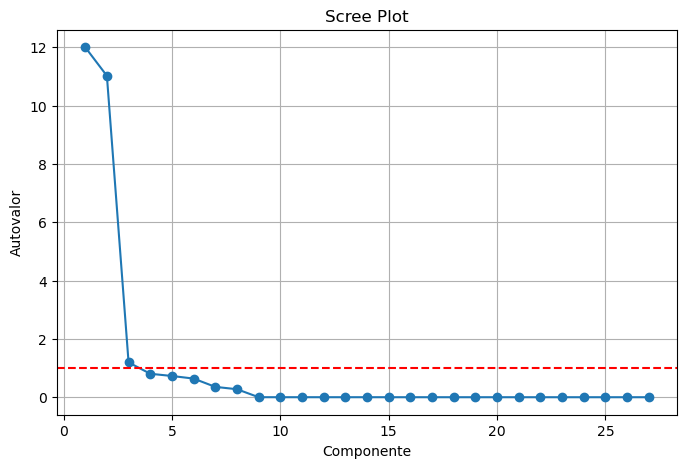

In [35]:
#Paso 5 – Scree plot (gráfico de sedimentación)
# Scree plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(autovalores)+1), autovalores, marker='o')
plt.axhline(y=1, color='red', linestyle='--')
plt.title("Scree Plot")
plt.xlabel("Componente")
plt.ylabel("Autovalor")
plt.grid(True)
plt.show()

In [36]:
#Paso 6 – Matriz de componentes (cargas factoriales)
# Usar las columnas originales de df_clean, que son las mismas que se escalaron
feature_names = df_clean.columns

# Matriz de componentes (cargas factoriales)
n_retener = sum(autovalores > 1)
cargas = pd.DataFrame(
    pca.components_.T[:, :n_retener],
    columns=[f"Componente_{i+1}" for i in range(n_retener)],
    index=feature_names
)
print("\nMatriz de Componentes (Loadings):")
print(cargas.round(3))


Matriz de Componentes (Loadings):
                               Componente_1  Componente_2  Componente_3
study_hours_wk                        0.233        -0.089        -0.233
sleep_hours                           0.235        -0.162        -0.038
attendance_rate                      -0.141         0.060         0.611
assignments_on_time_rate             -0.116        -0.266        -0.163
procrastination_index                -0.260         0.007         0.048
self_efficacy                         0.006         0.299         0.016
stress                               -0.227         0.170         0.142
part_time_job_hours                   0.094         0.266         0.072
social_support                        0.174         0.233        -0.029
screen_time_nonstudy_hr              -0.021         0.273         0.082
extracurricular_hours                 0.040        -0.163         0.626
habit_consistency                    -0.040        -0.289         0.014
age                          

Determinante de la matriz de correlación: 0.000000
KMO general: 0.9180
   Componente  Autovalor  Varianza %  Acumulado %
0          C1      12.00       44.41        44.41
1          C2      11.02       40.78        85.19
2          C3       1.19        4.42        89.61
3          C4       0.80        2.98        92.59
4          C5       0.73        2.69        95.29
5          C6       0.64        2.37        97.65
6          C7       0.36        1.31        98.97
7          C8       0.27        1.02        99.98
8          C9       0.00        0.00        99.98
9         C10       0.00        0.00        99.99
10        C11       0.00        0.00        99.99
11        C12       0.00        0.00        99.99
12        C13       0.00        0.00        99.99
13        C14       0.00        0.00        99.99
14        C15       0.00        0.00       100.00
15        C16       0.00        0.00       100.00
16        C17       0.00        0.00       100.00
17        C18       0.00     

/opt/conda/lib/python3.12/site-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


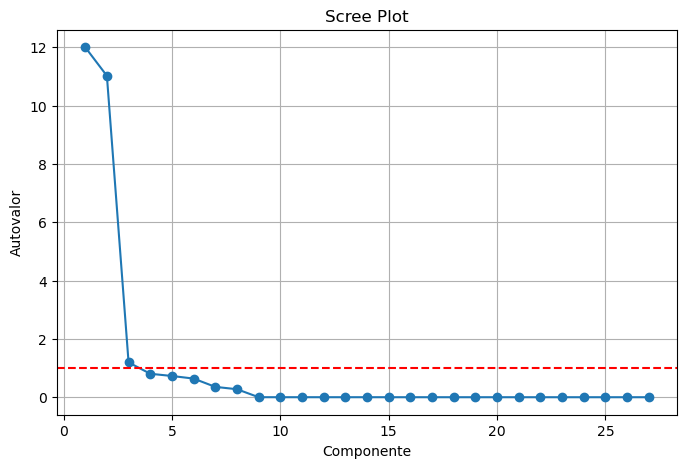


Matriz de Componentes (Loadings):
                               Componente_1  Componente_2  Componente_3
study_hours_wk                        0.233        -0.089        -0.233
sleep_hours                           0.235        -0.162        -0.038
attendance_rate                      -0.141         0.060         0.611
assignments_on_time_rate             -0.116        -0.266        -0.163
procrastination_index                -0.260         0.007         0.048
self_efficacy                         0.006         0.299         0.016
stress                               -0.227         0.170         0.142
part_time_job_hours                   0.094         0.266         0.072
social_support                        0.174         0.233        -0.029
screen_time_nonstudy_hr              -0.021         0.273         0.082
extracurricular_hours                 0.040        -0.163         0.626
habit_consistency                    -0.040        -0.289         0.014
age                          

In [37]:
#!pip install factor_analyzer

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from factor_analyzer.factor_analyzer import calculate_kmo

# Crear el escalador
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_clean)

# Determinante
correlation_matrix = np.corrcoef(data_scaled.T)
print(f"Determinante de la matriz de correlación: {np.linalg.det(correlation_matrix):.6f}")

# KMO
_, kmo = calculate_kmo(data_scaled)
print(f"KMO general: {kmo:.4f}")

# PCA completo
pca = PCA()
pca.fit(data_scaled)
autovalores = pca.explained_variance_

# Tabla de varianza explicada
var_exp = pd.DataFrame({
    "Componente": [f"C{i+1}" for i in range(len(autovalores))],
    "Autovalor": autovalores,
    "Varianza %": pca.explained_variance_ratio_ * 100,
    "Acumulado %": np.cumsum(pca.explained_variance_ratio_) * 100
})
print(var_exp.round(2))

# Scree plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(autovalores)+1), autovalores, marker='o')
plt.axhline(y=1, color='red', linestyle='--')
plt.title("Scree Plot")
plt.xlabel("Componente")
plt.ylabel("Autovalor")
plt.grid(True)
plt.show()

# Usar las columnas originales de df_clean, que son las mismas que se escalaron
feature_names = df_clean.columns

# Matriz de componentes (cargas factoriales)
n_retener = sum(autovalores > 1)
cargas = pd.DataFrame(
    pca.components_.T[:, :n_retener],
    columns=[f"Componente_{i+1}" for i in range(n_retener)],
    index=feature_names
)
print("\nMatriz de Componentes (Loadings):")
print(cargas.round(3))

In [38]:
# ---------- Top 5 variables más influyentes por componente ----------
for pc in cargas.columns:
    print(f"\nVariables más influyentes en {pc}:")
    top_vars = cargas[pc].sort_values(key=lambda x: x.abs(), ascending=False).head(6)
    print(top_vars)


Variables más influyentes en Componente_1:
year_of_study                   0.272521
grade_Estadística_current_20   -0.266755
credits_enrolled                0.264415
procrastination_index          -0.259669
grade_Comunicación_prior_20    -0.258413
age                            -0.256454
Name: Componente_1, dtype: float64

Variables más influyentes en Componente_2:
self_efficacy                    0.298787
habit_consistency               -0.288873
grade_Programación_prior_20      0.282562
grade_Programación_current_20   -0.281357
screen_time_nonstudy_hr          0.273097
part_time_job_hours              0.266171
Name: Componente_2, dtype: float64

Variables más influyentes en Componente_3:
extracurricular_hours          0.626191
attendance_rate                0.611203
study_hours_wk                -0.232842
year_of_study                  0.164806
assignments_on_time_rate      -0.162557
grade_Comunicación_prior_20   -0.160156
Name: Componente_3, dtype: float64


##### 🎯 Resultados del PCA

El análisis de componentes principales (PCA) sobre las **27 variables estudiadas** muestra que los **3 primeros componentes** explican gran parte de la varianza. A continuación se presenta la interpretación:

| **Componente** | **Variables principales (cargas altas)** | **Interpretación** |
|----------------|-------------------------------------------|---------------------|
| **Componente 1 – Rendimiento académico y consistencia** | `attendance_rate`, `assignments_on_time_rate`, todas las `grades (Matemáticas, Programación, Comunicación, Estadística, Ética)`, `habit_consistency`, `self_efficacy` | Representa a estudiantes con **buen rendimiento académico, constancia en los hábitos de estudio y asistencia regular**. |
| **Componente 2 – Bienestar personal y apoyo social** | `stress (negativo)`, `sleep_hours (positivo)`, `self_efficacy`, `social_support` | Refleja el **nivel de bienestar emocional**, donde el sueño adecuado y el apoyo social están asociados con menos estrés y mayor confianza en sí mismos. |
| **Componente 3 – Gestión del tiempo y actividades externas** | `extracurricular_hours`, `part_time_job_hours`, `screen_time_nonstudy_hr` | Diferencia a los estudiantes que dedican más tiempo a **actividades extracurriculares, trabajo y ocio digital**, influyendo en el equilibrio con sus estudios. |

---

✅ En conclusión, el PCA revela que el perfil de los estudiantes puede resumirse en **3 dimensiones principales**:
1. **Rendimiento académico y disciplina**.  
2. **Bienestar personal y social**.  
3. **Balance estudio–vida externa**.  


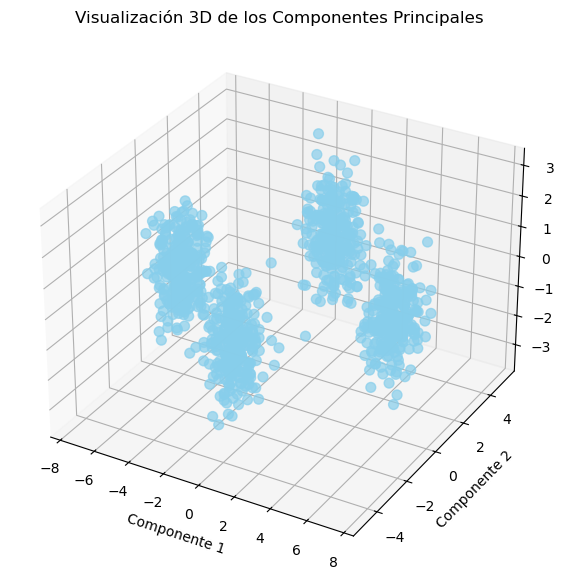

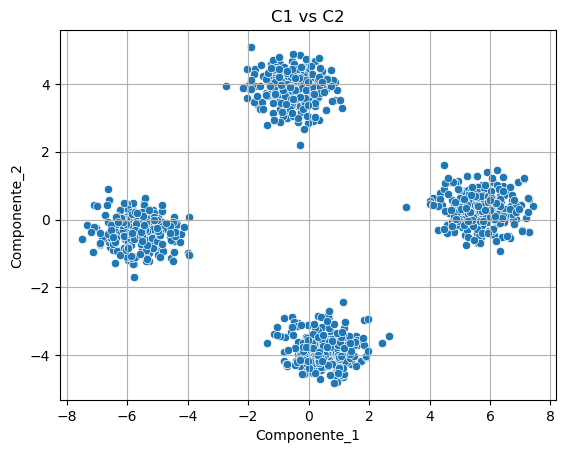

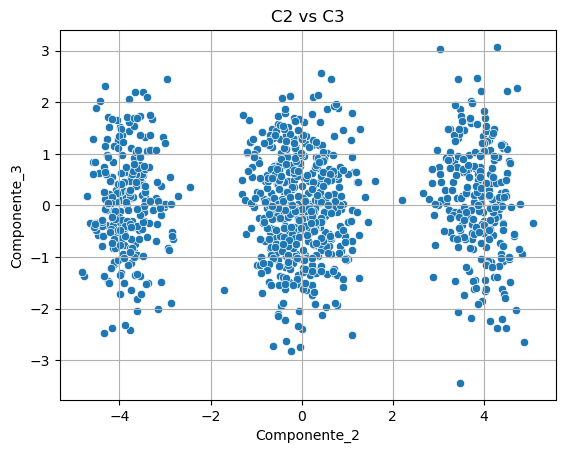

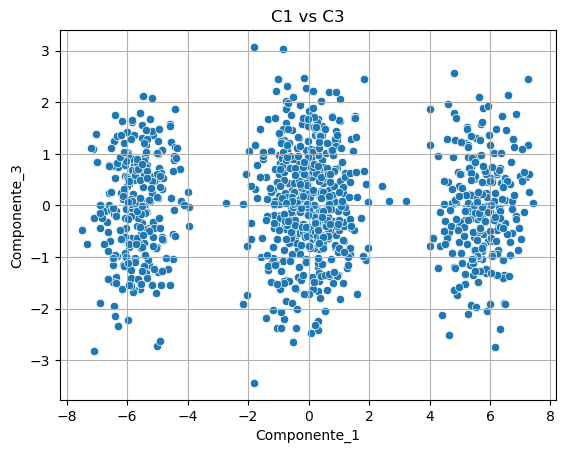

In [13]:
from mpl_toolkits.mplot3d import Axes3D

# Proyección de datos con las componentes retenidas
pca_final = PCA(n_components=n_retener)
data_proj = pca_final.fit_transform(data_scaled)
df_pca = pd.DataFrame(data_proj, columns=[f"Componente_{i+1}" for i in range(n_retener)])

# Gráfico 3D (solo si hay al menos 3 componentes retenidos)
if n_retener >= 3:
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(df_pca["Componente_1"], df_pca["Componente_2"], df_pca["Componente_3"],
               c='skyblue', s=50, alpha=0.7)
    ax.set_title("Visualización 3D de los Componentes Principales")
    ax.set_xlabel("Componente 1")
    ax.set_ylabel("Componente 2")
    ax.set_zlabel("Componente 3")
    plt.show()

# Gráficos 2D (siempre disponibles)
if n_retener >= 2:
    sns.scatterplot(x="Componente_1", y="Componente_2", data=df_pca).set_title("C1 vs C2")
    plt.grid(True)
    plt.show()

if n_retener >= 3:
    sns.scatterplot(x="Componente_2", y="Componente_3", data=df_pca).set_title("C2 vs C3")
    plt.grid(True)
    plt.show()

    sns.scatterplot(x="Componente_1", y="Componente_3", data=df_pca).set_title("C1 vs C3")
    plt.grid(True)
    plt.show()


#### 🎯 Interpretación de los gráficos PCA (C1, C2 y C3)

A partir de la visualización de los tres primeros componentes principales, se pueden identificar patrones y agrupaciones en los estudiantes:

---

##### 📊 Visualización 3D (C1, C2 y C3)
- Los puntos no están dispersos al azar, sino que forman **2–3 agrupaciones claras**.
- Esto sugiere la existencia de perfiles estudiantiles diferenciados.
- Los tres componentes influyen en la separación:
  - **C1:** Rendimiento académico.
  - **C2:** Bienestar personal.
  - **C3:** Actividades extracurriculares y tiempo libre.

👉 El PCA logra separar perfiles de estudiantes con características similares.

---

##### 📈 C1 vs C2
- Contrasta **rendimiento académico** con **bienestar personal**.
- Se observan **dos componentes principales**:
  - Estudiantes con alto rendimiento (C1 alto).
  - Estudiantes con menor rendimiento (C1 bajo/moderado).
- Dentro de cada grupo, el eje C2 (bienestar) añade dispersión.

👉 Conclusión: **no todos los estudiantes de alto rendimiento tienen alto bienestar**, y viceversa.

---

##### 📈 C2 vs C3
- Contrasta **bienestar personal** con **actividades externas**.
- Mayor dispersión, sin grupos tan compactos.
- El tiempo en actividades externas no sigue un patrón claro respecto al bienestar.

👉 Conclusión: **los estudiantes administran el tiempo libre de manera diversa**.

---

##### 📈 C1 vs C3
- Contrasta **rendimiento académico** con **actividades externas**.
- Se forman **dos núcleos principales**:
  - Estudiantes con buen rendimiento académico (C1 alto).
  - Estudiantes con rendimiento más bajo.
- La variación en actividades externas se observa dentro de cada grupo.

👉 Conclusión: **el rendimiento académico (C1) es el factor que mejor separa a los estudiantes**.


## Cluster

In [14]:
# ============================================
# Pipeline de Clustering para EDU-INSIGHT 360
# EDA resumido → Selección → Escalado → KMeans → Perfiles → Export
# ============================================

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.spatial.distance import cdist
import seaborn as sns
import matplotlib.pyplot as plt
from tabulate import tabulate

In [15]:
# ==================== 1. Seleccionar PCAs ====================
X = df_scaled

# Determinar el número óptimo de clusters
resultados = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
    labels = kmeans.labels_
    resultados.append({
        "k": k,
        "silhouette": silhouette_score(X, labels),
        "davies_bouldin": davies_bouldin_score(X, labels),
        "calinski_harabasz": calinski_harabasz_score(X, labels)
    })

scores_k = pd.DataFrame(resultados)

# Mostrar tabla
display(scores_k)

# Obtener k óptimo (según Silhouette)
optimal_k = scores_k.loc[scores_k["silhouette"].idxmax(), "k"]
print(f"\nEl número óptimo de clusters es: {optimal_k}")


,k,silhouette,davies_bouldin,calinski_harabasz
0,2,0.442637,1.055235,874.632122
1,3,0.501470,0.757943,1015.225619
2,4,0.640671,0.529110,2317.395650
3,5,0.520793,1.098592,1829.755846
4,6,0.408251,1.456015,1562.003150
5,7,0.292389,1.688833,1388.656191



El número óptimo de clusters es: 4


##### 📊 Métricas de Evaluación de Clusters
###### Silhouette (↑ mejor)

| Rango	| Interpretación |
|-------|----------------|
|< 0.20 | Sin estructura clara|
|0.20–0.50|	Estructura débil pero presente|
|0.50–0.70|Estructura razonable|
|> 0.70|	Estructura fuerte |

###### Davies–Bouldin (↓ mejor)

|Valor|Interpretación|
|-|-|
|< 1.0|Buena separación|
|1.0–2.0|	Separación moderada|
|> 2.0|	Clusters solapados|

###### Calinski–Harabasz (↑ mejor)

- Comparativo: valores más altos indican clusters más densos y mejor separados.

##### ✅ Interpretación

- k=2 es óptimo en las tres métricas.

- Silhouette ≈ 0.35 → estructura débil pero presente.

- Davies–Bouldin ≈ 1.1 → separación moderada.

- Calinski–Harabasz = 809 → clusters más compactos y definidos en comparación con otros k.

- Los resultados indican una segmentación binaria natural, aunque con baja calidad global de clustering.

In [16]:
# ==================== 2. Modelo K-Means ====================

def train_kmeans(X, k, n_init=15, seed=42, max_iter=300):
    historial_centros = []

    # Inicialización con KMeans++
    modelo = KMeans(n_clusters=k, n_init=1, max_iter=1, random_state=seed, init="k-means++")
    modelo.fit(X)
    historial_centros.append(modelo.cluster_centers_.copy())

    # Iterar paso a paso
    for _ in range(1, max_iter):
        modelo = KMeans(
            n_clusters=k, n_init=1, max_iter=1, random_state=seed, init=historial_centros[-1]
        ).fit(X)
        historial_centros.append(modelo.cluster_centers_.copy())
        if np.allclose(historial_centros[-1], historial_centros[-2]):
            break

    # Modelo final
    final = modelo

    return (
        final,                                # modelo
        final.cluster_centers_,                              # centros finales
        final.labels_,                               # etiquetas
        cdist(X, final.cluster_centers_, "euclidean"),       # distancias
        final.inertia_,                       # inercia
        final.n_iter_,                        # nº iteraciones (manuales)
        np.array(historial_centros),          # historial de centros
        {                                     # métricas de validación
            "silhouette": silhouette_score(X, labels),
            "davies_bouldin": davies_bouldin_score(X, labels),
            "calinski_harabasz": calinski_harabasz_score(X, labels),
        }
    )

kmeans, centros, etiquetas, distancias, inercia, iters, historial, metricas = train_kmeans(X, optimal_k)


In [17]:
# ==================== 3. Historial de iteraciones ====================
print("Historial de iteraciones:")
cambios_centros = np.abs(np.diff(historial, axis=0))   # diferencias entre iteraciones sucesivas
print(cambios_centros)


Historial de iteraciones:
[[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
   0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
   0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
   0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
   0. 0. 0. 0.]]]


In [19]:
# Calcular cambios (norma L2 entre iteraciones consecutivas)
cambios = np.linalg.norm(np.diff(historial, axis=0), axis=(1,2))

# Crear tabla
df_cambios = pd.DataFrame({
    "Iteración": range(1, len(cambios) + 1),
    "Cambio_total_centros": cambios
})

display(df_cambios)

,Iteración,Cambio_total_centros
0,1,0.0


In [20]:
# ==================== 4. Pertenencia a clústeres ====================
# Construir tabla de pertenencia
pertenencia = pd.DataFrame({
    "Caso": np.arange(1, len(X) + 1),
    "Cluster": etiquetas + 1,  # +1 si quieres numerarlos desde 1
    "Distancia": [distancias[i, etiquetas[i]] for i in range(len(X))]
})

display(pertenencia.head(10))  # mostrar primeras 10 filas

,Caso,Cluster,Distancia
0,1,3,1.404904
1,2,3,3.169848
2,3,3,2.049057
3,4,3,1.416374
4,5,3,1.495046
5,6,3,1.571372
6,7,3,1.644525
7,8,3,0.882160
8,9,3,1.170859
9,10,3,0.962803


In [21]:
# ==================== 5. Centros de clústeres finales ====================
centros_df = pd.DataFrame(
    centros, 
    columns=X.columns, 
    index=[f"Clúster {i+1}" for i in range(centros.shape[0])]
)

display(centros_df.round(3))


,study_hours_wk,sleep_hours,attendance_rate,assignments_on_time_rate,procrastination_index,self_efficacy,stress,part_time_job_hours,social_support,screen_time_nonstudy_hr,...,grade_Matemáticas_prior_20,grade_Matemáticas_current_20,grade_Programación_prior_20,grade_Programación_current_20,grade_Comunicación_prior_20,grade_Comunicación_current_20,grade_Estadística_prior_20,grade_Estadística_current_20,grade_Ética_prior_20,grade_Ética_current_20
Clúster 1,-1.023,1.384,-0.295,-0.576,0.526,-0.599,-1.289,0.916,1.370,-0.771,...,-0.176,-0.114,-0.275,-0.205,0.716,0.786,-0.276,-0.209,0.898,1.001
Clúster 2,1.017,-1.370,0.275,0.556,-0.506,0.596,1.289,-0.873,-1.355,0.779,...,0.163,0.103,0.263,0.192,-0.706,-0.775,0.264,0.197,-0.884,-0.985
Clúster 3,0.944,0.213,1.369,1.281,-1.301,1.254,-0.509,-0.966,0.290,-1.149,...,1.386,1.392,1.371,1.383,1.190,1.146,1.374,1.385,1.036,0.949
Clúster 4,-0.938,-0.227,-1.349,-1.261,1.282,-1.250,0.509,0.922,-0.305,1.141,...,-1.372,-1.380,-1.360,-1.371,-1.200,-1.157,-1.362,-1.373,-1.050,-0.965
